In [1]:
import matplotlib.pyplot as plt
import torch
from cryosim.plotting_tools import *
from cryosim.imagegenerator import MicrographGenerator
import torch.nn.functional as F
from rich.progress import track
from cryosim.pdbtools import PDB
from cryosim.potential import PotentialBuilder
%load_ext autoreload
%autoreload 2

In [2]:
# fetch pdb file
pdb_code = "6bdf"
assembly = True # True: fetches assembly. False: fetches subunit. int: fetches specific assembly #int
pdb = PDB(pdb_code, assembly=True, savefolder="../pdb-data/")

Assemblies available: 1
6bdf: Fetching default Biological Assembly 1
File already exists: ../pdb-data/6bdf-assembly1.cif, skip fetching.


Output()

In [3]:
# Samples 3D scattering potential onto specified grid
n = 256  # number of pixels per axis
dx = 1  # angstrom, pixel size.
device = 'cpu'
pb = PotentialBuilder(n, dx, pdb.atomic_numbers, pdb.coordinates, verbose=True).to(device)

In [4]:
with torch.no_grad():
    V = pb().clone()

Output()

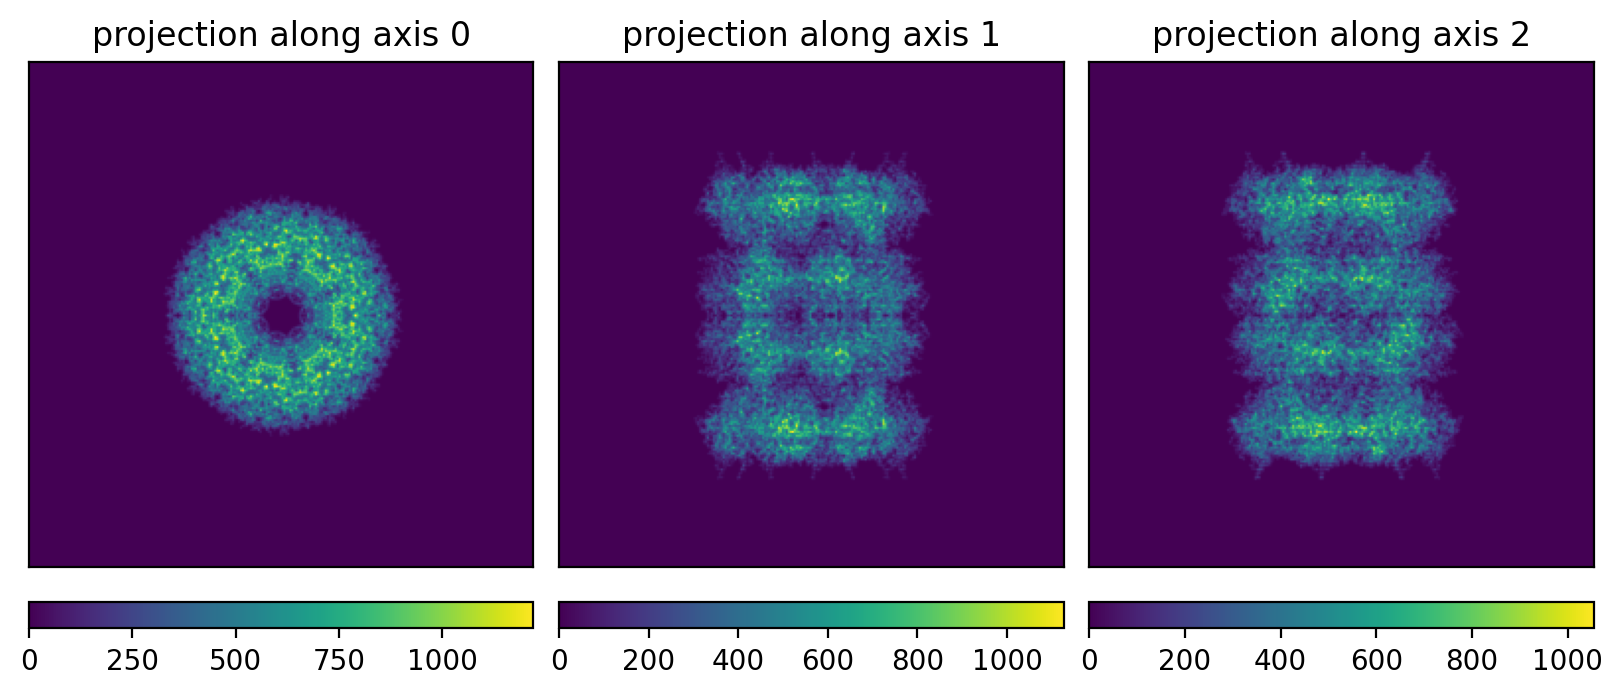

In [5]:
plot3d(V)

## Micrograph class

In [6]:
n_micrographs = 1
energy = 300  # keV
dose_per_angstrom = 20  # e-/A^2
Cs = 2e7  # angstrom. Sherical aberration, typical values are 1-3 mm.
alpha = 0.1
micrograph_size = 2048

In [7]:
# random defocus
defocus_min = 5000  # angstrom
defocus_max = 15000  # angstrom
dfang = 0
defocus_A = torch.rand(n_micrographs) * (defocus_max - defocus_min) + defocus_min

# fixed defocus
# defocus_A = 10000 * torch.ones(n_particles)

# beamtilt
tiltx = 0.0
tilty = 0.0

# phaseshift
phaseshift = 0

# trefoil
tref1 = 0
tref2 = 0
# [Cs, dfu, dfv, dfang, tiltx, tilty, phaseshift, tref1, tref2]
ctf_params = torch.stack(
    [
        torch.tensor([Cs, d, d, dfang, tiltx, tilty, phaseshift, tref1, tref2])
        for d in defocus_A
    ]
)
ctf_params.shape

torch.Size([1, 9])

In [8]:
device = "cuda:0"  # choose cpu if you run out of cuda memory.

In [9]:
# Use multislice, holography, poisson and random_choice to obtain close to experimental conditions.
scattering_model = "multislice"  # 'multislice', 'firstborn', 'projection', 'ctf'
aberration_model = "holography"  # 'holography' or 'ctf'

noise_model = "poisson"  # 'poisson' or None
# noise_model = None

ice_model = 'iterative'  # 'randomchoice' for fast & inaccurate, 'iterative' for slow & accurate, or None
# ice_model = None

ice_thickness = 1000  # angstroms, set to 0 for minimum ice thickness = particle box size

crowd_min_distance = pdb.max_diameter # angstroms, set to None for no crowding
# crowd_min_distance = None

crowd_max_distance_z = pdb.max_diameter # if None, defaults to ice_thickness which would result in too many particles above each other.

pad_fft = False # True to avoid edge artifacts when if crowd_min_distance is not None
# pad_fft = True

chunk_size = 8 # set to None for no chunking (cuda memory might exceed)

model = MicrographGenerator(
    V,
    micrograph_size,
    dx,
    ctf_params,
    energy,
    dose_per_angstrom,
    ice_model=ice_model,
    ice_thickness=ice_thickness,
    scattering_model=scattering_model,
    aberration_model=aberration_model,
    noise_model=noise_model,
    klim=None,
    alpha=alpha,
    crowd_min_distance=crowd_min_distance,
    crowd_max_distance_z=crowd_max_distance_z,
    pad_fft=pad_fft,
    chunk_size=chunk_size,
    move_to_cpu=True
).to(device)

In [10]:
idx = torch.arange(n_micrographs)
images = []
batchsize = 1  # set higher or lower for faster/slower generation.
with torch.no_grad():
    for i in track(range(0, n_micrographs, batchsize), description='Generating micrographs'):
        image = model(idx[i : i + batchsize])
        images.append(image.detach().cpu())

images = torch.concat(images, dim=0)
images.shape

Output()

Scattering

Aberrating

Imaging

torch.Size([1, 2048, 2048])

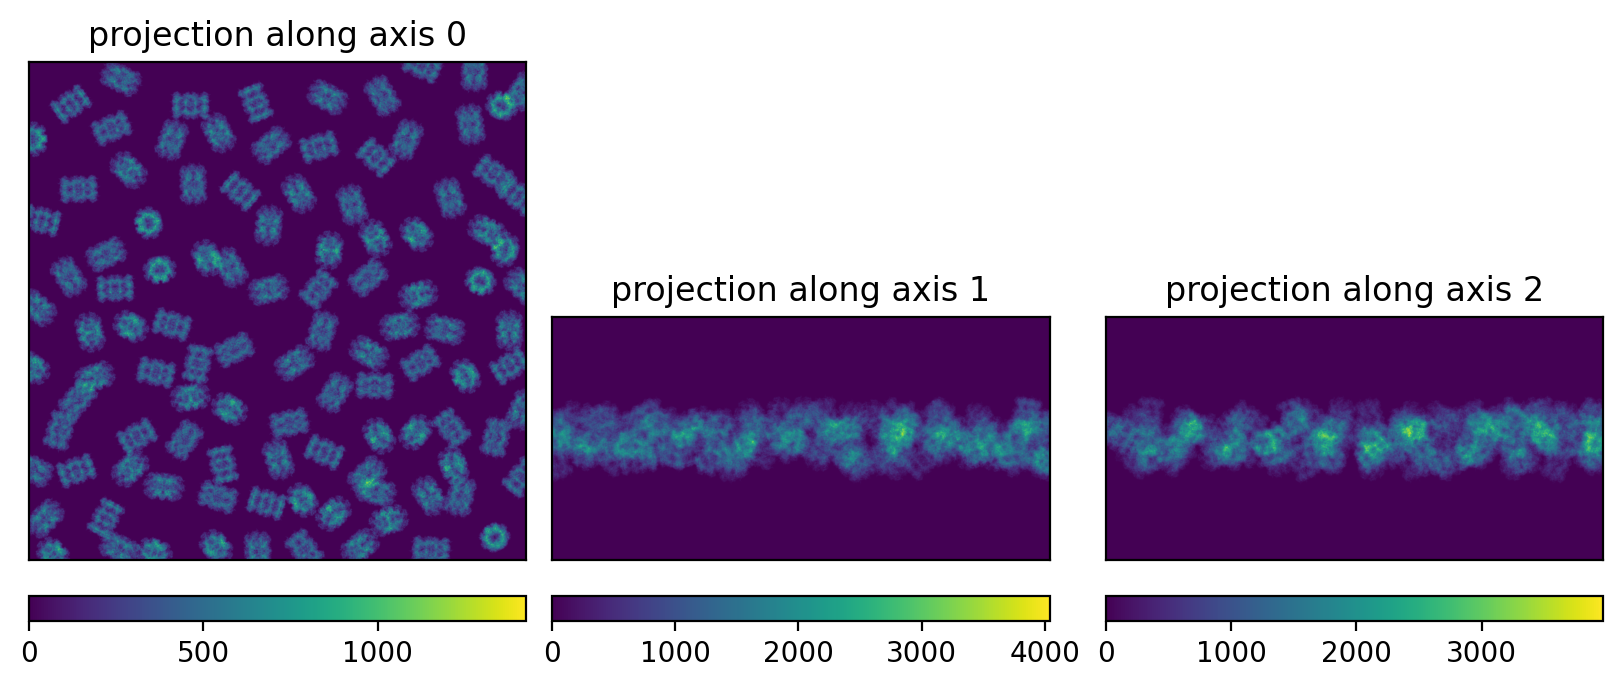

In [11]:
plot3d(model.vols.detach().cpu())

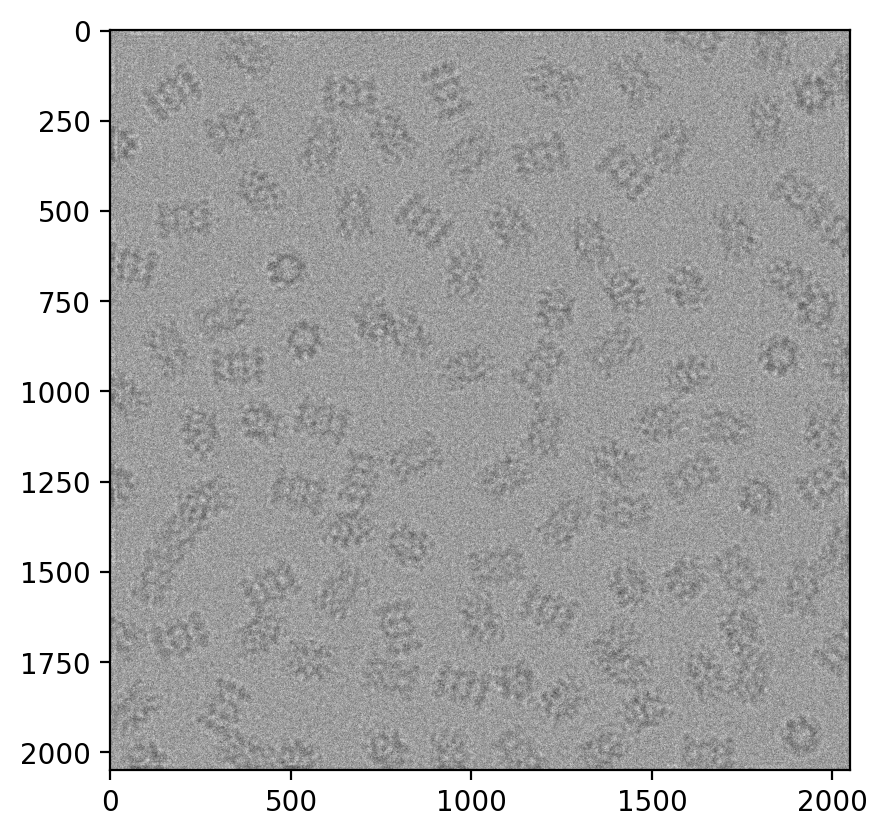

In [12]:
plt.figure(dpi=200)
plt.imshow(images[0], cmap='grey', vmin=0, vmax=25)

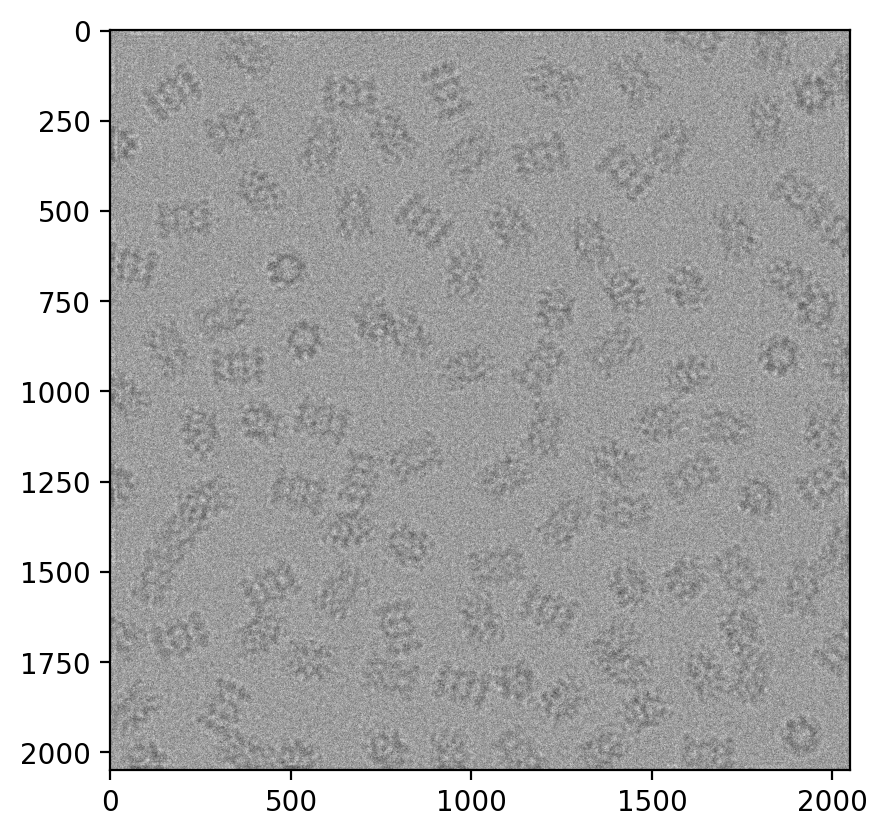

In [13]:
plt.figure(dpi=200)
plt.imshow(images[0], cmap='grey', vmin=0, vmax=25)

In [14]:
import mrcfile

In [15]:
# for i, im in enumerate(images):
#     with mrcfile.new(f'/scratch/loh/joel/czii/micrograph{i}.mrcs', overwrite=True) as mrc:
#         mrc.set_data(im.numpy())

In [16]:
# def create_particle_starfile(
#     particles,
#     rotations=None,
#     translations=None,
#     alpha=0.1,
#     folderpath='',
#     energy=None,
#     dx=None,
#     starfilename='particles',
#     mrcfilename=None,
#     ctf_params=None
# ):

In [17]:
# fig, axes = plt.subplots(1, 5, dpi=200, constrained_layout=True, figsize=(10, 5))
# for i, ax in enumerate(axes.ravel()):
#     im = ax.imshow(images[i], cmap="grey")
#     ax.set(xticks=[], yticks=[])
#     ax.set_title(f"Defocus: {ctf_params[i,2]/10000:.2f} $\mu$m")
#     fig.colorbar(im, ax=ax, location="bottom")
# plt.show()